In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_analysis = pd.read_csv('../data/raw/analysis.csv')

In [3]:
df_analysis.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237650e+18,48.824760,-8.166999,19.44393,18.43291,18.11620,17.98857,17.95942,1045,301,1,98,3.587172e+18,STAR,-0.000996,3186,54853,201
1,1.237658e+18,193.394684,52.336221,22.41654,22.09867,20.53718,19.63900,19.28375,2830,301,4,454,7.513333e+18,GALAXY,0.518672,6673,56419,739
2,1.237679e+18,324.020999,10.000606,19.49719,17.58264,16.66178,16.18781,15.85648,7777,301,5,87,4.608454e+18,GALAXY,0.077720,4093,55475,530
3,1.237666e+18,234.965903,23.031949,24.31149,21.99310,20.58364,19.76995,19.39575,4671,301,5,41,4.445071e+18,GALAXY,0.471659,3948,55331,66
4,1.237665e+18,170.706066,35.630196,25.61850,24.86680,21.37659,19.77067,19.26844,4504,301,1,94,5.199500e+18,GALAXY,0.720088,4618,55600,343


In [4]:
print(df_analysis.isnull().sum())

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [5]:
df_analysis.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.237665e+18,176.413341,24.072838,22.057796,20.612774,19.628704,19.065712,18.754885,4481.871500,301.0,3.515500,183.364000,5.777500e+18,0.581698,5131.341200,55590.078000,448.176600
std,8.432263e+12,96.756173,19.667583,2.241957,2.039581,1.862932,1.760867,1.778200,1963.298966,0.0,1.590916,146.992926,3.301292e+18,0.749837,2932.120447,1795.522704,273.548417
min,1.237646e+18,0.044805,-17.573820,13.947160,11.745180,10.863790,10.566470,10.778890,109.000000,301.0,1.000000,11.000000,2.996469e+17,-0.005675,266.000000,51608.000000,1.000000
25%,1.237659e+18,126.763327,5.254813,20.323692,18.946545,18.076622,17.690020,17.425365,3184.750000,301.0,2.000000,80.000000,2.889124e+18,0.056119,2566.000000,54243.000000,218.000000
50%,1.237663e+18,180.490960,23.456502,22.178960,21.060670,20.086700,19.370560,18.973020,4188.000000,301.0,4.000000,144.000000,5.627958e+18,0.412175,4998.500000,55888.000000,428.000000
75%,1.237668e+18,232.391345,39.911293,23.687152,22.132447,21.039848,20.367310,19.889990,5330.000000,301.0,5.000000,236.000000,8.248439e+18,0.697583,7326.000000,56748.000000,645.000000
max,1.237681e+18,359.993568,83.000519,29.325650,27.414650,29.571860,32.141470,28.790550,8162.000000,301.0,6.000000,977.000000,1.412675e+19,7.011245,12547.000000,58932.000000,1000.000000


In [6]:
print(df_analysis['class'].value_counts(normalize=True))

class
GALAXY    0.5945
STAR      0.2159
QSO       0.1896
Name: proportion, dtype: float64


In [7]:
df_analysis['class'].describe()

count      10000
unique         3
top       GALAXY
freq        5945
Name: class, dtype: object

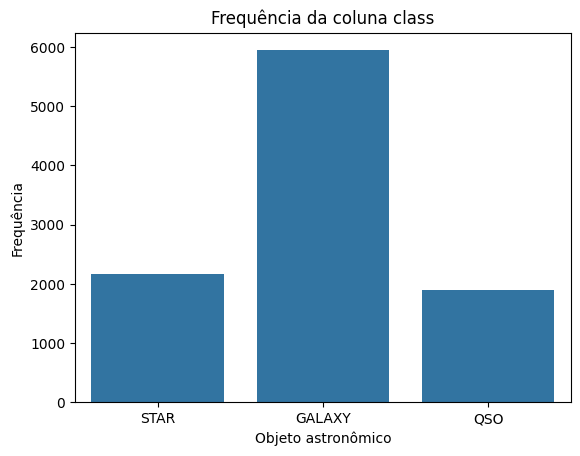

In [8]:
sns.countplot(data=df_analysis, x='class')
plt.title("Frequência da coluna class")
plt.xlabel("Objeto astronômico")
plt.ylabel("Frequência")

plt.show()

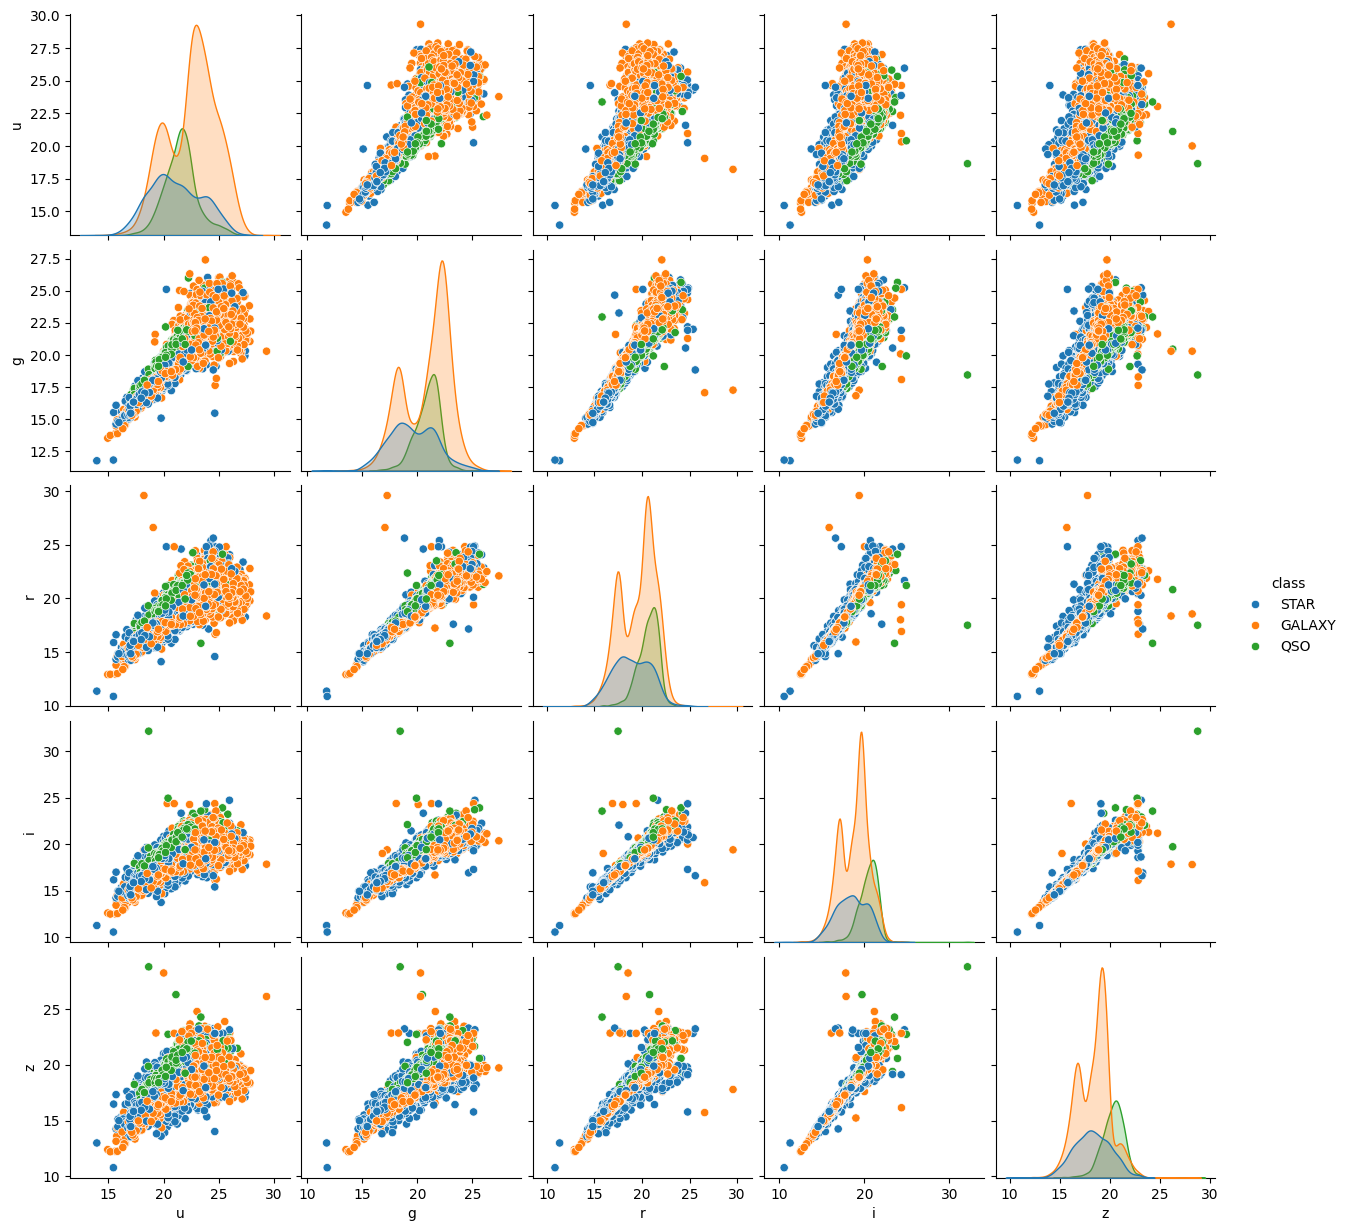

In [9]:
sns.pairplot(df_analysis, hue='class', vars=['u', 'g', 'r', 'i', 'z'])
plt.show()

Todas as variáveis são positivamente correlacionadas entre si

In [10]:
variables = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

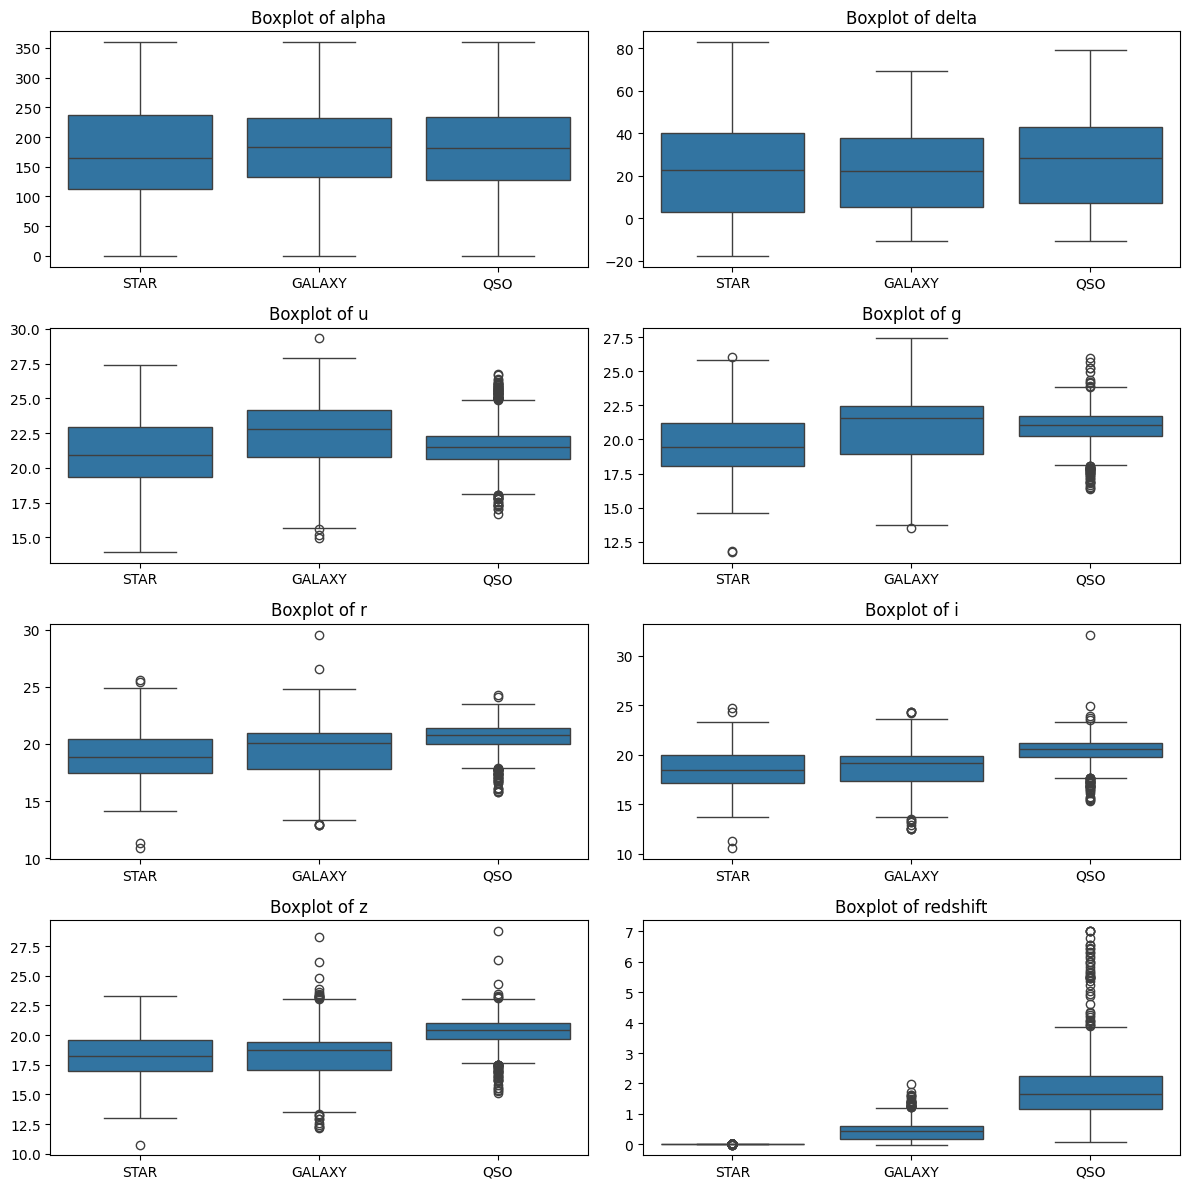

In [11]:
#Boxplot das variáveis em relação às classes (sem tratamento de outliers)

plt.figure(figsize=(12, 12))  # Ajuste conforme o número de variáveis

for idx, var in enumerate(variables):
    plt.subplot(4, 2, idx + 1)  # 4 linhas x 2 colunas
    sns.boxplot(x='class', y=var, data=df_analysis)
    plt.title(f'Boxplot of {var}')
    plt.xlabel('')  # Remove label para estética
    plt.ylabel('')

plt.tight_layout()
plt.show()

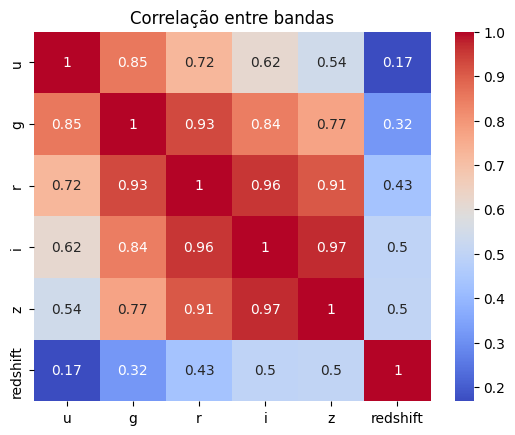

In [12]:
corr = df_analysis[['u', 'g', 'r', 'i', 'z', 'redshift']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação entre bandas')
plt.show()

Há uma correlação alta entre u-g, g-i, g-r, r-i, r-z, i-z

In [13]:
#remoção de outliers

def remove_outliers_iqr(dataframe, columns):
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        before = dataframe.shape[0]
        dataframe = dataframe[(dataframe[col] >= lower_bound) & (dataframe[col] <= upper_bound)]
        after = dataframe.shape[0]
        print(f'{col}: removed {before - after} outliers')
    return dataframe

In [14]:
#outliers removidos

df_limpo = remove_outliers_iqr(df_analysis, variables)

alpha: removed 0 outliers
delta: removed 0 outliers
u: removed 4 outliers
g: removed 4 outliers
r: removed 5 outliers
i: removed 6 outliers
z: removed 14 outliers
redshift: removed 945 outliers


In [15]:
print(df_limpo.shape)
print(df_limpo.describe())

(9022, 18)
             obj_ID        alpha        delta            u            g  \
count  9.022000e+03  9022.000000  9022.000000  9022.000000  9022.000000   
mean   1.237665e+18   176.078367    23.878083    22.093792    20.582500   
std    8.418377e+12    96.512911    19.709729     2.292127     2.093473   
min    1.237646e+18     0.044805   -17.573820    15.472450    14.607690   
25%    1.237659e+18   126.573561     5.026099    20.242328    18.748297   
50%    1.237663e+18   180.513353    23.095914    22.281325    21.044105   
75%    1.237668e+18   232.252905    39.494692    23.796345    22.197918   
max    1.237681e+18   359.993568    83.000519    27.886380    26.323280   

                 r            i            z       run_ID  rerun_ID  \
count  9022.000000  9022.000000  9022.000000  9022.000000    9022.0   
mean     19.515203    18.911869    18.582169  4465.292729     301.0   
std       1.865900     1.718023     1.715726  1960.066003       0.0   
min      14.192130    13.9499

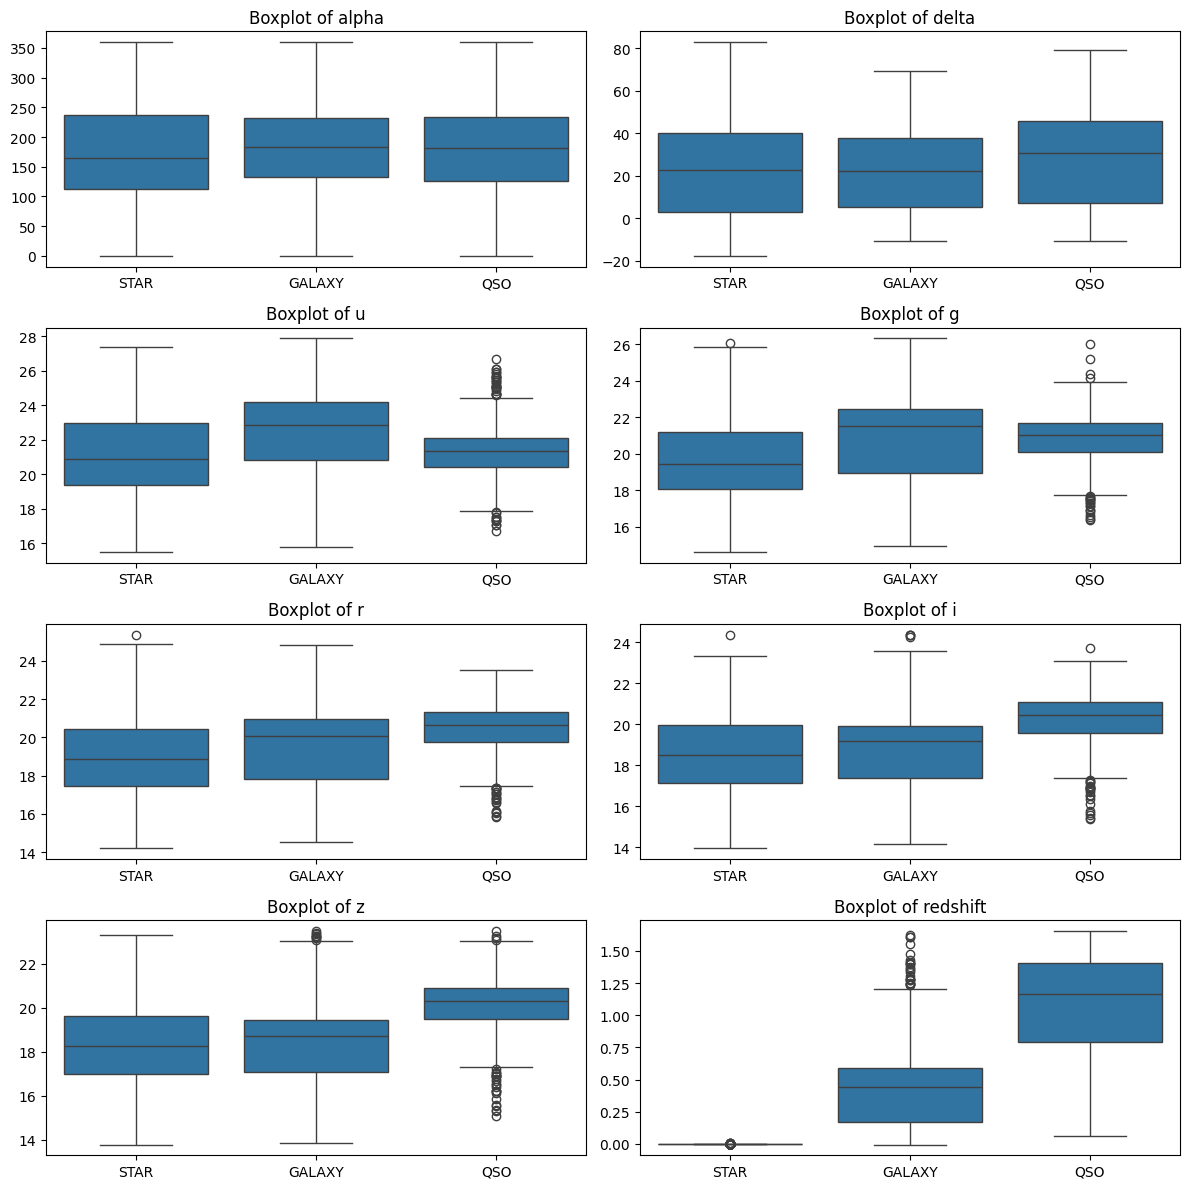

In [16]:
#Boxplot das variáveis em relação às classes (com tratamento para outliers)

plt.figure(figsize=(12, 12))  # Ajuste conforme o número de variáveis

for idx, var in enumerate(variables):
    plt.subplot(4, 2, idx + 1)  # 4 linhas x 2 colunas
    sns.boxplot(x='class', y=var, data=df_limpo)
    plt.title(f'Boxplot of {var}')
    plt.xlabel('')  # Remove label para estética
    plt.ylabel('')

plt.tight_layout()
plt.show()

1 - Qual é a importância relativa das diferentes bandas espectrais para a discriminação entre classes?

In [17]:
# Conclusões sobre a distribuição das variáveis {'u', 'g', 'r', 'i', 'z'} (entendi que são essas as bandas espectrais)
# São linearmente separáveis, obedecem uma distribuição em comum, é possível classificar uma classe a partir de algum desses espectros?

2 - Como se distribuem espacialmente os objetos classificados?

[]

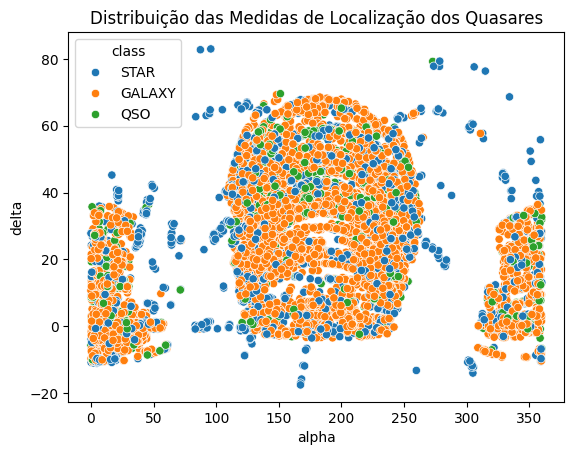

In [18]:
sns.scatterplot(df_limpo,
                x='alpha',
                y='delta',
                hue='class')
plt.title("Distribuição das Medidas de Localização dos Quasares")
plt.plot()

In [19]:
df_limpo.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

3 - De que maneira o redshift impacta os processos de classificação?

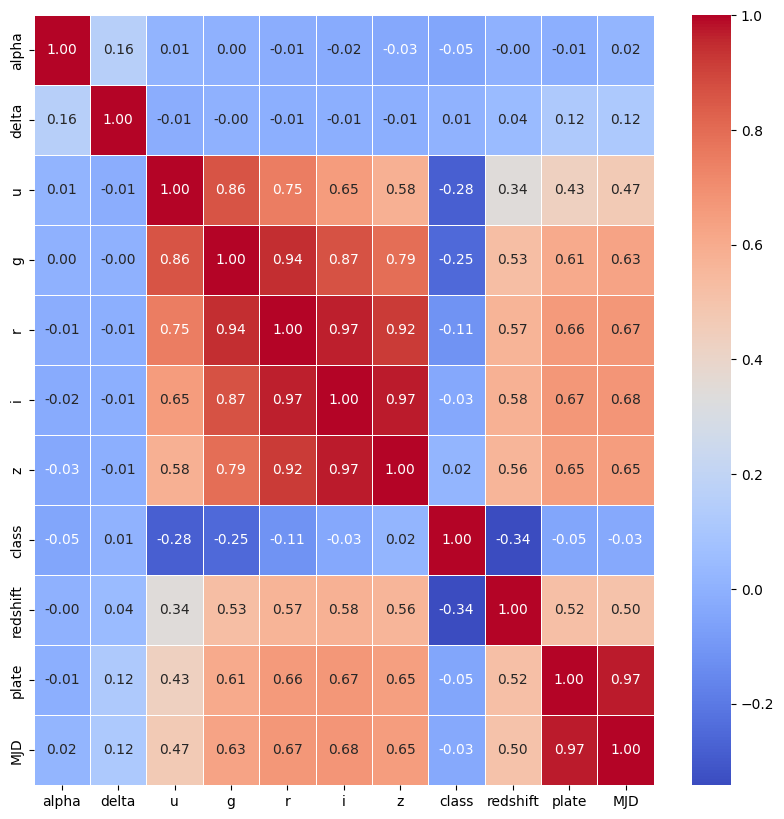

In [20]:
from sklearn.preprocessing import LabelEncoder
df0 = df_limpo.copy()
label_encoder = LabelEncoder()
df0['class'] = label_encoder.fit_transform(df0['class'])

df0 = df0.drop(["obj_ID", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID", "fiber_ID"], axis=1)

plt.figure(figsize=(10, 10))
sns.heatmap(df0.corr(), annot = True, fmt = ".2f", linewidths = .5, cmap='coolwarm')
plt.show()

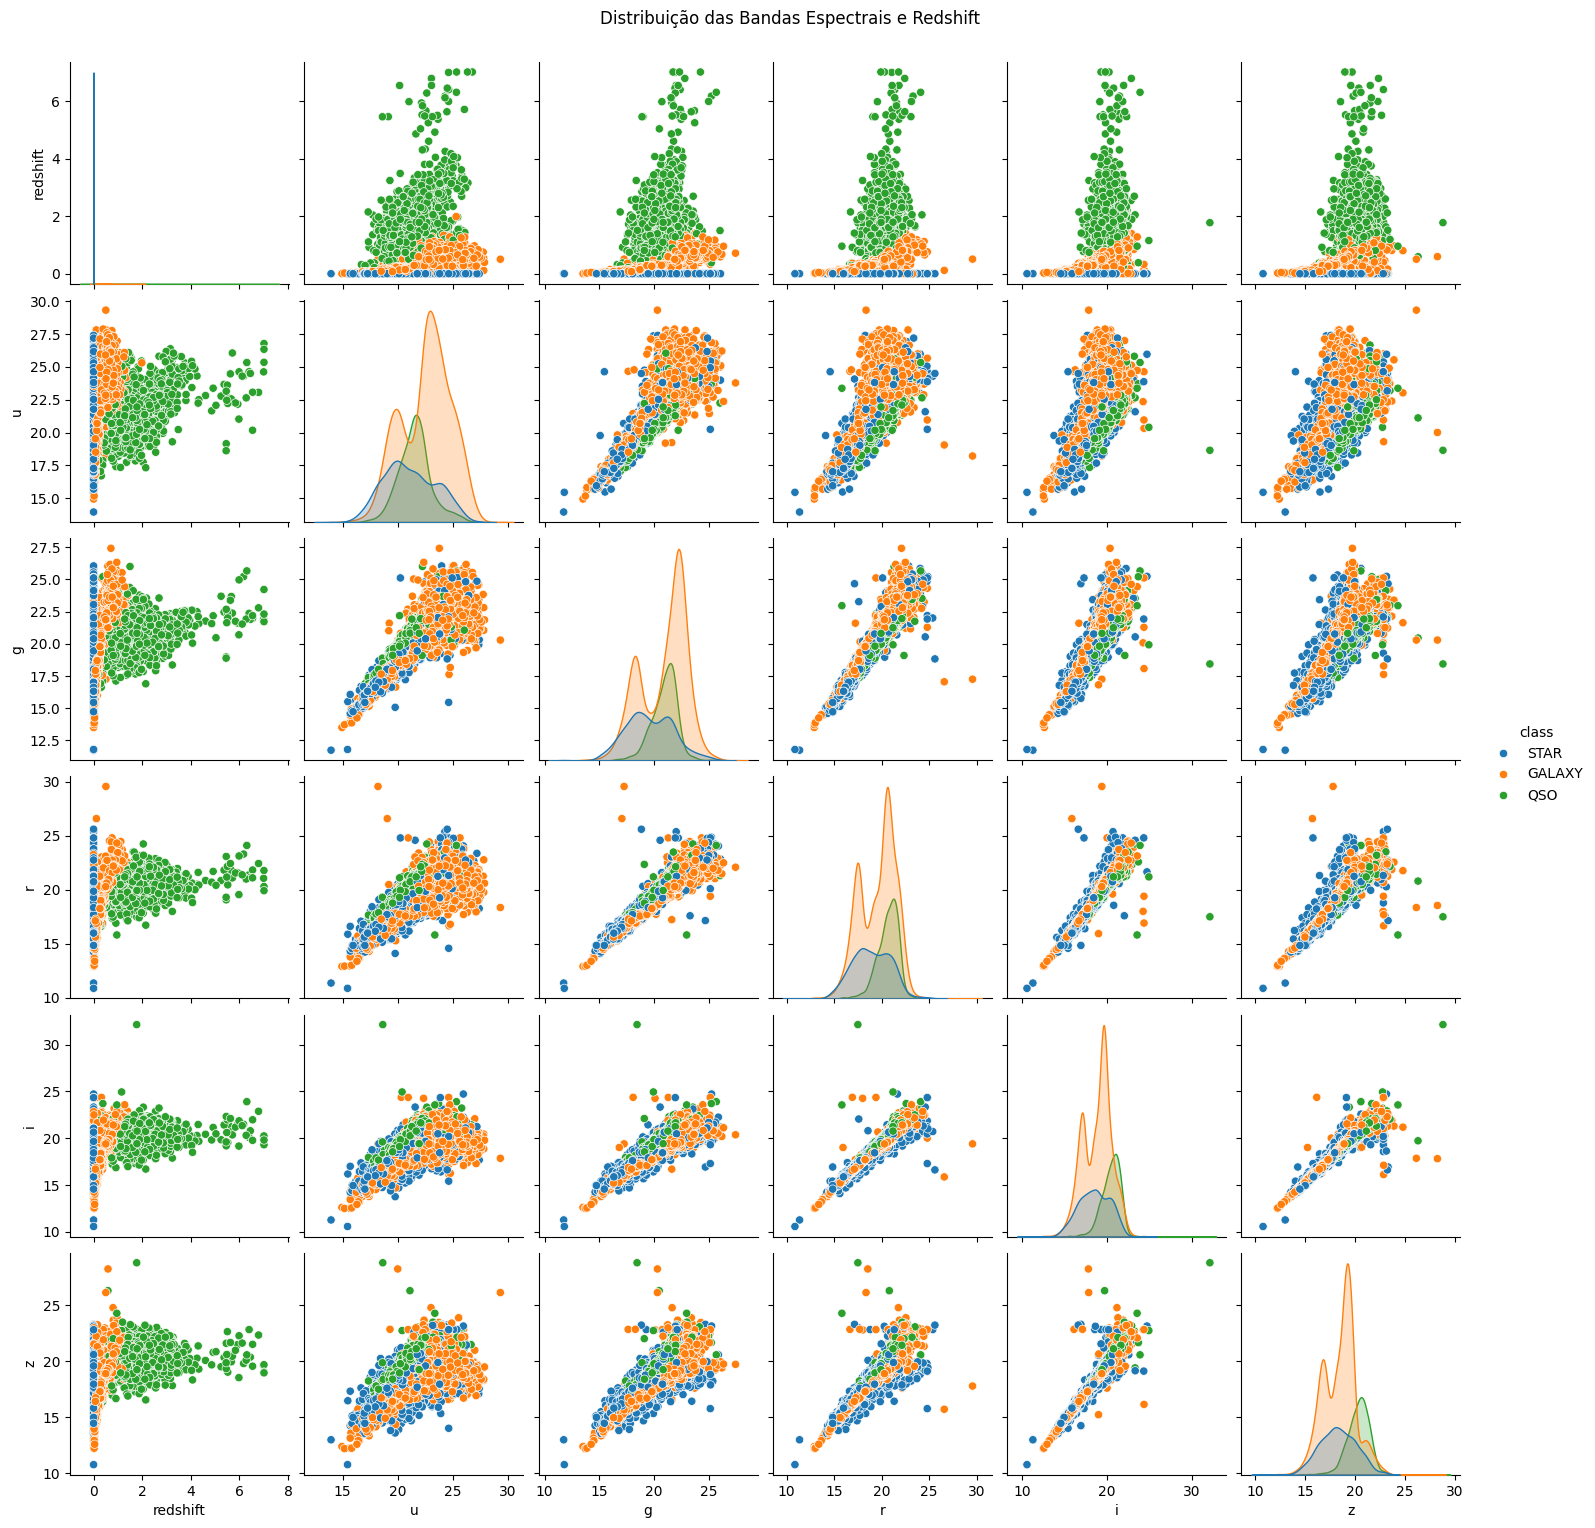

In [21]:
feat = ['redshift',
        # 'alpha',
        # 'delta',
        'u',
        'g',
        'r',
        'i',
        'z']

g = sns.pairplot(df_analysis, hue='class', vars=feat)
g.fig.suptitle("Distribuição das Bandas Espectrais e Redshift", y=1.02)
plt.show()

4 - Existem possíveis subgrupos dentro das categorias principais?
